# VRPTW → E-VRPTW: Data Analysis and Conversion

This notebook analyzes Schneider-style VRPTW / fuel-routing instance files and converts them into **EVRP-ready** format for the Transformer MARL project.

**Read-only source:** `dataset/vrptw_instances/`  
**Write target:** `dataset/evrptw_instances/`

Fuel terminology is reinterpreted as electric-vehicle terminology:
- fuel tank → battery capacity
- fuel consumption → energy consumption
- refueling stations → charging stations

In [1]:
# --- Imports and path configuration ---
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("ggplot")

# Resolve paths relative to this notebook location (dataset/)
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "dataset":
    # Fallback when launched from project root
    candidate = NOTEBOOK_DIR / "dataset"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

RAW_DIR = NOTEBOOK_DIR / "vrptw_instances"
CONVERTED_DIR = NOTEBOOK_DIR / "evrptw_instances"
CONVERTED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook directory : {NOTEBOOK_DIR}")
print(f"Raw instances dir  : {RAW_DIR}")
print(f"Converted output   : {CONVERTED_DIR}")

Notebook directory : C:\Users\AYOUB\OneDrive - EMSI\Bureau\PHD_WORK\Transformer_MARL_EVRP\dataset
Raw instances dir  : C:\Users\AYOUB\OneDrive - EMSI\Bureau\PHD_WORK\Transformer_MARL_EVRP\dataset\vrptw_instances
Converted output   : C:\Users\AYOUB\OneDrive - EMSI\Bureau\PHD_WORK\Transformer_MARL_EVRP\dataset\evrptw_instances


## 1. Discover raw instance files

Load all `.txt` instance files from `dataset/vrptw_instances/` (excluding `readme.txt`).

In [2]:
# Collect raw instance file paths
raw_files = sorted(RAW_DIR.glob("*.txt"))
raw_files = [f for f in raw_files if f.name.lower() != "readme.txt"]

print(f"Number of instance files found: {len(raw_files)}")
print("\nFile names (first 10):")
for f in raw_files[:10]:
    print(f"  - {f.name}")
if len(raw_files) > 10:
    print(f"  ... and {len(raw_files) - 10} more")

Number of instance files found: 92

File names (first 10):
  - c101_21.txt
  - c101C10.txt
  - c101C5.txt
  - c102_21.txt
  - c103_21.txt
  - c103C15.txt
  - c103C5.txt
  - c104_21.txt
  - c104C10.txt
  - c105_21.txt
  ... and 82 more


## 2. Analyze the original data format

Each Schneider-style file contains:

**Node table columns:**
- `StringID`, `Type`, `x`, `y`, `demand`, `ReadyTime`, `DueDate`, `ServiceTime`

**Node types:**
- `d` = depot
- `f` = fuel / recharging station
- `c` = customer

**Global parameters (at end of file):**
- `Q` Vehicle fuel tank capacity
- `C` Vehicle load capacity
- `r` fuel consumption rate
- `g` inverse refueling rate
- `v` average Velocity

In [3]:
# Show the raw structure of one example file
EXAMPLE_FILE = raw_files[0]
print(f"Example file: {EXAMPLE_FILE.name}\n")
print("=" * 80)
example_text = EXAMPLE_FILE.read_text(encoding="utf-8")
print(example_text[:2500])
if len(example_text) > 2500:
    print("\n... [truncated] ...\n")
    print(example_text[-400:])

Example file: c101_21.txt

StringID   Type       x          y          demand     ReadyTime  DueDate    ServiceTime 
D0         d          40.0       50.0       0.0        0.0        1236.0     0.0        
S0         f          40.0       50.0       0.0        0.0        1236.0     0.0        
S1         f          73.0       52.0       0.0        0.0        1236.0     0.0        
S2         f          90.0       55.0       0.0        0.0        1236.0     0.0        
S3         f          55.0       79.0       0.0        0.0        1236.0     0.0        
S4         f          69.0       89.0       0.0        0.0        1236.0     0.0        
S5         f          32.0       80.0       0.0        0.0        1236.0     0.0        
S6         f          39.0       96.0       0.0        0.0        1236.0     0.0        
S7         f          23.0       80.0       0.0        0.0        1236.0     0.0        
S8         f          4.0        83.0       0.0        0.0        1236.0     0.0  

## 3. Terminology mapping (fuel → EVRP energy notation)

| Original | EVRP |
|---|---|
| `d` | depot |
| `f` | charging_station |
| `c` | customer |
| `Q` Vehicle fuel tank capacity | `battery_capacity` |
| `C` Vehicle load capacity | `load_capacity` |
| `r` fuel consumption rate | `energy_consumption_rate` |
| `g` inverse refueling rate | `inverse_charging_rate` |
| `v` average Velocity | `speed` |

In [4]:
# --- Parsing and conversion utilities ---

NODE_COLUMNS = [
    "StringID", "Type", "x", "y", "demand",
    "ReadyTime", "DueDate", "ServiceTime",
]

TYPE_TO_NODE_TYPE = {
    "d": "depot",
    "f": "charging_station",
    "c": "customer",
}

RAW_PARAMETER_MAPPING = {
    "Q": "Vehicle fuel tank capacity -> battery_capacity",
    "C": "Vehicle load capacity -> load_capacity",
    "r": "fuel consumption rate -> energy_consumption_rate",
    "g": "inverse refueling rate -> inverse_charging_rate",
    "v": "average Velocity -> speed",
}

PARAM_PATTERNS = {
    "Q": re.compile(r"Q\s+Vehicle fuel tank capacity\s+/([\d.+-eE]+)/"),
    "C": re.compile(r"C\s+Vehicle load capacity\s+/([\d.+-eE]+)/"),
    "r": re.compile(r"r\s+fuel consumption rate\s+/([\d.+-eE]+)/"),
    "g": re.compile(r"g\s+inverse refueling rate\s+/([\d.+-eE]+)/"),
    "v": re.compile(r"v\s+average Velocity\s+/([\d.+-eE]+)/"),
}

COORD_EPS = 1e-6


def parse_raw_instance(filepath: Path) -> tuple[pd.DataFrame, dict[str, float]]:
    """Parse a Schneider-style VRPTW/fuel instance file into a node table and raw parameters."""
    lines = filepath.read_text(encoding="utf-8").strip().splitlines()

    node_rows: list[dict] = []
    raw_params: dict[str, float] = {}

    for line in lines[1:]:  # skip header
        stripped = line.strip()
        if not stripped:
            continue

        # Global vehicle parameters appear at the end of the file
        matched_param = False
        for key, pattern in PARAM_PATTERNS.items():
            m = pattern.search(stripped)
            if m:
                raw_params[key] = float(m.group(1))
                matched_param = True
                break
        if matched_param:
            continue

        parts = stripped.split()
        if len(parts) < 8:
            continue

        node_rows.append({
            "StringID": parts[0],
            "Type": parts[1],
            "x": float(parts[2]),
            "y": float(parts[3]),
            "demand": float(parts[4]),
            "ReadyTime": float(parts[5]),
            "DueDate": float(parts[6]),
            "ServiceTime": float(parts[7]),
        })

    nodes_df = pd.DataFrame(node_rows, columns=NODE_COLUMNS)

    missing = [k for k in PARAM_PATTERNS if k not in raw_params]
    if missing:
        raise ValueError(f"Missing parameters {missing} in {filepath.name}")

    return nodes_df, raw_params


def _coords_equal(x1: float, y1: float, x2: float, y2: float, eps: float = COORD_EPS) -> bool:
    return abs(x1 - x2) <= eps and abs(y1 - y2) <= eps


def convert_to_evrp(
    nodes_df: pd.DataFrame,
    raw_params: dict[str, float],
    instance_name: str,
) -> tuple[dict, pd.DataFrame, dict[str, np.ndarray]]:
    """Convert parsed raw data into EVRP JSON structure, node CSV rows, and matrices."""

    battery_capacity = raw_params["Q"]
    load_capacity = raw_params["C"]
    energy_consumption_rate = raw_params["r"]
    inverse_charging_rate = raw_params["g"]
    speed = raw_params["v"]

    vehicle_parameters = {
        "battery_capacity": battery_capacity,
        "load_capacity": load_capacity,
        "energy_consumption_rate": energy_consumption_rate,
        "inverse_charging_rate": inverse_charging_rate,
        "speed": speed,
    }

    # Locate depot (D0) coordinates for S0 co-location check
    depot_rows = nodes_df[nodes_df["Type"] == "d"]
    if depot_rows.empty:
        raise ValueError(f"No depot found in {instance_name}")
    depot_row = depot_rows.iloc[0]
    depot_x, depot_y = float(depot_row["x"]), float(depot_row["y"])

    s0_row = nodes_df[nodes_df["StringID"] == "S0"]
    s0_co_located = False
    if not s0_row.empty:
        s0 = s0_row.iloc[0]
        s0_co_located = _coords_equal(depot_x, depot_y, float(s0["x"]), float(s0["y"]))

    converted_nodes: list[dict] = []
    for idx, row in nodes_df.iterrows():
        original_type = row["Type"]
        node_type = TYPE_TO_NODE_TYPE[original_type]
        is_depot = original_type == "d"
        is_customer = original_type == "c"
        is_charging_station = original_type == "f"

        demand = float(row["demand"])
        if is_charging_station:
            demand = 0.0

        node = {
            "id": int(idx),
            "string_id": row["StringID"],
            "original_type": original_type,
            "node_type": node_type,
            "x": float(row["x"]),
            "y": float(row["y"]),
            "demand": demand,
            "ready_time": float(row["ReadyTime"]),
            "due_time": float(row["DueDate"]),
            "service_time": float(row["ServiceTime"]),
            "is_depot": is_depot,
            "is_customer": is_customer,
            "is_charging_station": is_charging_station,
        }

        if row["StringID"] == "S0" and s0_co_located:
            node["co_located_with_depot"] = True

        converted_nodes.append(node)

    depot_indices = [n["id"] for n in converted_nodes if n["is_depot"]]
    customer_indices = [n["id"] for n in converted_nodes if n["is_customer"]]
    charging_station_indices = [n["id"] for n in converted_nodes if n["is_charging_station"]]
    depot_index = depot_indices[0]
    rechargeable_indices = [depot_index] + charging_station_indices

    # Planning horizon for normalization
    depot_due = next((n["due_time"] for n in converted_nodes if n["is_depot"]), None)
    if depot_due is None or depot_due <= 0:
        planning_horizon = max(n["due_time"] for n in converted_nodes)
    else:
        planning_horizon = depot_due

    xs = np.array([n["x"] for n in converted_nodes], dtype=float)
    ys = np.array([n["y"] for n in converted_nodes], dtype=float)
    max_abs_coordinate = max(float(np.max(np.abs(xs))), float(np.max(np.abs(ys))))
    if max_abs_coordinate == 0:
        max_abs_coordinate = 1.0

    # Matrices
    n_nodes = len(converted_nodes)
    dx = xs[:, None] - xs[None, :]
    dy = ys[:, None] - ys[None, :]
    distance_matrix = np.sqrt(dx ** 2 + dy ** 2)
    travel_time_matrix = distance_matrix / speed
    energy_matrix = distance_matrix * energy_consumption_rate

    # Build nodes.csv with normalized ML features
    csv_rows = []
    for node in converted_nodes:
        csv_row = dict(node)
        csv_row["x_norm"] = node["x"] / max_abs_coordinate
        csv_row["y_norm"] = node["y"] / max_abs_coordinate
        csv_row["demand_norm"] = node["demand"] / load_capacity
        csv_row["ready_time_norm"] = node["ready_time"] / planning_horizon
        csv_row["due_time_norm"] = node["due_time"] / planning_horizon
        csv_row["service_time_norm"] = node["service_time"] / planning_horizon
        csv_rows.append(csv_row)

    nodes_csv_df = pd.DataFrame(csv_rows)

    metadata = {
        "instance_name": instance_name,
        "problem_type": "E-VRPTW",
        "source_folder": "dataset/vrptw_instances",
        "converted_folder": "dataset/evrptw_instances",
        "source_format": "Schneider-style VRPTW/fuel notation",
        "converted_to": "EVRP energy notation",
        "num_depots": len(depot_indices),
        "num_customers": len(customer_indices),
        "num_charging_stations": len(charging_station_indices),
        "depot_has_charging": bool(s0_co_located),
        "planning_horizon": planning_horizon,
        "max_abs_coordinate": max_abs_coordinate,
    }

    index_sets = {
        "depot_index": depot_index,
        "customer_indices": customer_indices,
        "charging_station_indices": charging_station_indices,
        "rechargeable_indices": rechargeable_indices,
    }

    evrp_instance = {
        "metadata": metadata,
        "vehicle_parameters": vehicle_parameters,
        "raw_parameter_mapping": RAW_PARAMETER_MAPPING,
        "index_sets": index_sets,
        "nodes": converted_nodes,
    }

    matrices = {
        "distance_matrix": distance_matrix,
        "travel_time_matrix": travel_time_matrix,
        "energy_matrix": energy_matrix,
    }

    return evrp_instance, nodes_csv_df, matrices


def validate_instance(evrp_instance: dict, matrices: dict[str, np.ndarray]) -> list[str]:
    """Run validation checks; return list of error messages (empty if all pass)."""
    errors: list[str] = []
    name = evrp_instance["metadata"]["instance_name"]
    nodes = evrp_instance["nodes"]
    vp = evrp_instance["vehicle_parameters"]
    idx = evrp_instance["index_sets"]

    depots = [n for n in nodes if n["is_depot"]]
    customers = [n for n in nodes if n["is_customer"]]
    stations = [n for n in nodes if n["is_charging_station"]]

    if len(depots) != 1:
        errors.append(f"[{name}] Expected exactly 1 depot, found {len(depots)}")
    if len(customers) < 1:
        errors.append(f"[{name}] Expected at least 1 customer, found {len(customers)}")
    if len(stations) < 1:
        errors.append(f"[{name}] Expected at least 1 charging station, found {len(stations)}")

    for c in customers:
        if c["demand"] <= 0:
            errors.append(f"[{name}] Customer {c['string_id']} has invalid demand {c['demand']}")
        if c["ready_time"] > c["due_time"]:
            errors.append(
                f"[{name}] Customer {c['string_id']}: ready_time > due_time"
            )

    for s in stations:
        if s["demand"] != 0.0:
            errors.append(f"[{name}] Station {s['string_id']} demand must be 0, got {s['demand']}")

    for key in ["battery_capacity", "load_capacity", "energy_consumption_rate", "inverse_charging_rate", "speed"]:
        if vp[key] <= 0:
            errors.append(f"[{name}] {key} must be positive, got {vp[key]}")

    for n in nodes:
        if not np.isfinite(n["x"]) or not np.isfinite(n["y"]):
            errors.append(f"[{name}] Node {n['string_id']} has invalid coordinates")

    n_nodes = len(nodes)
    for mname, mat in matrices.items():
        if mat.shape != (n_nodes, n_nodes):
            errors.append(f"[{name}] {mname} shape {mat.shape} != ({n_nodes}, {n_nodes})")
        if not np.allclose(np.diag(mat), 0.0):
            errors.append(f"[{name}] {mname} diagonal is not zero")

    return errors


def check_reachability_warnings(evrp_instance: dict, matrices: dict[str, np.ndarray]) -> list[str]:
    """Warn when depot->customer->recharge round-trip energy exceeds battery capacity."""
    warnings: list[str] = []
    name = evrp_instance["metadata"]["instance_name"]
    battery = evrp_instance["vehicle_parameters"]["battery_capacity"]
    depot_idx = evrp_instance["index_sets"]["depot_index"]
    rechargeable = evrp_instance["index_sets"]["rechargeable_indices"]
    energy = matrices["energy_matrix"]

    for c_idx in evrp_instance["index_sets"]["customer_indices"]:
        energy_depot_to_j = energy[depot_idx, c_idx]
        min_energy_j_to_recharge = min(energy[c_idx, r] for r in rechargeable)
        required_energy = energy_depot_to_j + min_energy_j_to_recharge
        if required_energy > battery:
            cust_id = evrp_instance["nodes"][c_idx]["string_id"]
            warnings.append(
                f"[{name}] Customer {cust_id}: required_energy={required_energy:.4f} > "
                f"battery_capacity={battery:.4f} (may need intermediate charging)"
            )
    return warnings


def save_converted_instance(
    output_dir: Path,
    evrp_instance: dict,
    nodes_csv_df: pd.DataFrame,
    matrices: dict[str, np.ndarray],
    validation_errors: list[str],
    reachability_warnings: list[str],
) -> None:
    """Write evrp_instance.json, nodes.csv, matrices.npz, and summary.json."""
    output_dir.mkdir(parents=True, exist_ok=True)

    with open(output_dir / "evrp_instance.json", "w", encoding="utf-8") as f:
        json.dump(evrp_instance, f, indent=2)

    nodes_csv_df.to_csv(output_dir / "nodes.csv", index=False)

    np.savez_compressed(
        output_dir / "matrices.npz",
        distance_matrix=matrices["distance_matrix"],
        travel_time_matrix=matrices["travel_time_matrix"],
        energy_matrix=matrices["energy_matrix"],
    )

    meta = evrp_instance["metadata"]
    vp = evrp_instance["vehicle_parameters"]
    summary = {
        "instance_name": meta["instance_name"],
        "num_nodes": len(evrp_instance["nodes"]),
        "num_customers": meta["num_customers"],
        "num_charging_stations": meta["num_charging_stations"],
        "depot_has_charging": meta["depot_has_charging"],
        "planning_horizon": meta["planning_horizon"],
        **vp,
        "validation_passed": len(validation_errors) == 0,
        "validation_errors": validation_errors,
        "reachability_warning_count": len(reachability_warnings),
    }
    with open(output_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)


print("Parser and conversion utilities loaded.")

Parser and conversion utilities loaded.


## 4. Parse and preview one example instance

In [5]:
# Parse the example file and preview raw node table
example_raw_df, example_raw_params = parse_raw_instance(EXAMPLE_FILE)

print(f"Parsed: {EXAMPLE_FILE.name}")
print(f"\nRaw vehicle parameters:")
for k, v in example_raw_params.items():
    print(f"  {k} = {v}")

print(f"\nNode count by type:")
print(example_raw_df["Type"].value_counts().rename({"d": "depot", "f": "station", "c": "customer"}))

display(example_raw_df.head(10))
display(example_raw_df.tail(5))

Parsed: c101_21.txt

Raw vehicle parameters:
  Q = 79.69
  C = 200.0
  r = 1.0
  g = 3.39
  v = 1.0

Node count by type:
Type
customer    100
station      21
depot         1
Name: count, dtype: int64


,StringID,Type,x,y,demand,ReadyTime,DueDate,ServiceTime
0,D0,d,40.0,50.0,0.0,0.0,1236.0,0.0
1,S0,f,40.0,50.0,0.0,0.0,1236.0,0.0
2,S1,f,73.0,52.0,0.0,0.0,1236.0,0.0
3,S2,f,90.0,55.0,0.0,0.0,1236.0,0.0
4,S3,f,55.0,79.0,0.0,0.0,1236.0,0.0
5,S4,f,69.0,89.0,0.0,0.0,1236.0,0.0
6,S5,f,32.0,80.0,0.0,0.0,1236.0,0.0
7,S6,f,39.0,96.0,0.0,0.0,1236.0,0.0
8,S7,f,23.0,80.0,0.0,0.0,1236.0,0.0
9,S8,f,4.0,83.0,0.0,0.0,1236.0,0.0


,StringID,Type,x,y,demand,ReadyTime,DueDate,ServiceTime
117,C96,c,60.0,80.0,10.0,177.0,243.0,90.0
118,C97,c,60.0,85.0,30.0,645.0,707.0,90.0
119,C98,c,58.0,75.0,20.0,181.0,247.0,90.0
120,C99,c,55.0,80.0,10.0,836.0,896.0,90.0
121,C100,c,55.0,85.0,20.0,744.0,798.0,90.0


## 5. Convert all instances to EVRP format

For each raw file, create `dataset/evrptw_instances/<instance_name>/` with:
- `evrp_instance.json`
- `nodes.csv`
- `matrices.npz`
- `summary.json`

In [6]:
# Batch conversion loop
conversion_records: list[dict] = []
all_validation_errors: list[str] = []
all_reachability_warnings: list[str] = []
converted_instances: dict[str, dict] = {}  # name -> {evrp, nodes_df, matrices, raw_df}

for raw_path in raw_files:
    instance_name = raw_path.stem
    raw_df, raw_params = parse_raw_instance(raw_path)
    evrp, nodes_csv_df, matrices = convert_to_evrp(raw_df, raw_params, instance_name)

    val_errors = validate_instance(evrp, matrices)
    reach_warnings = check_reachability_warnings(evrp, matrices)
    all_validation_errors.extend(val_errors)
    all_reachability_warnings.extend(reach_warnings)

    out_dir = CONVERTED_DIR / instance_name
    save_converted_instance(out_dir, evrp, nodes_csv_df, matrices, val_errors, reach_warnings)

    meta = evrp["metadata"]
    vp = evrp["vehicle_parameters"]
    conversion_records.append({
        "instance_name": instance_name,
        "num_nodes": len(evrp["nodes"]),
        "num_customers": meta["num_customers"],
        "num_charging_stations": meta["num_charging_stations"],
        "battery_capacity": vp["battery_capacity"],
        "load_capacity": vp["load_capacity"],
        "energy_consumption_rate": vp["energy_consumption_rate"],
        "inverse_charging_rate": vp["inverse_charging_rate"],
        "speed": vp["speed"],
        "planning_horizon": meta["planning_horizon"],
    })

    converted_instances[instance_name] = {
        "evrp": evrp,
        "nodes_df": nodes_csv_df,
        "matrices": matrices,
        "raw_df": raw_df,
    }

summary_df = pd.DataFrame(conversion_records)
print(f"Converted {len(conversion_records)} instances.")

Converted 92 instances.


## 6. Analysis visualizations

Detailed plots use the first example instance; the summary table covers all converted instances.

In [7]:
# Use the example instance for detailed visual analysis
example_name = EXAMPLE_FILE.stem
ex = converted_instances[example_name]
ex_evrp = ex["evrp"]
ex_nodes = ex["nodes_df"]
ex_raw = ex["raw_df"]
ex_matrices = ex["matrices"]

customers = ex_nodes[ex_nodes["is_customer"]]
depots = ex_nodes[ex_nodes["is_depot"]]
stations = ex_nodes[ex_nodes["is_charging_station"]]

print(f"Detailed analysis for: {example_name}")
print(f"  Depots             : {len(depots)}")
print(f"  Customers          : {len(customers)}")
print(f"  Charging stations  : {len(stations)}")
print(f"  Depot has charging : {ex_evrp['metadata']['depot_has_charging']}")

Detailed analysis for: c101_21
  Depots             : 1
  Customers          : 100
  Charging stations  : 21
  Depot has charging : True


In [8]:
# Table preview of raw parsed nodes
print("Raw parsed nodes (preview):")
display(ex_raw.head(12))

Raw parsed nodes (preview):


,StringID,Type,x,y,demand,ReadyTime,DueDate,ServiceTime
0,D0,d,40.0,50.0,0.0,0.0,1236.0,0.0
1,S0,f,40.0,50.0,0.0,0.0,1236.0,0.0
2,S1,f,73.0,52.0,0.0,0.0,1236.0,0.0
3,S2,f,90.0,55.0,0.0,0.0,1236.0,0.0
4,S3,f,55.0,79.0,0.0,0.0,1236.0,0.0
5,S4,f,69.0,89.0,0.0,0.0,1236.0,0.0
6,S5,f,32.0,80.0,0.0,0.0,1236.0,0.0
7,S6,f,39.0,96.0,0.0,0.0,1236.0,0.0
8,S7,f,23.0,80.0,0.0,0.0,1236.0,0.0
9,S8,f,4.0,83.0,0.0,0.0,1236.0,0.0


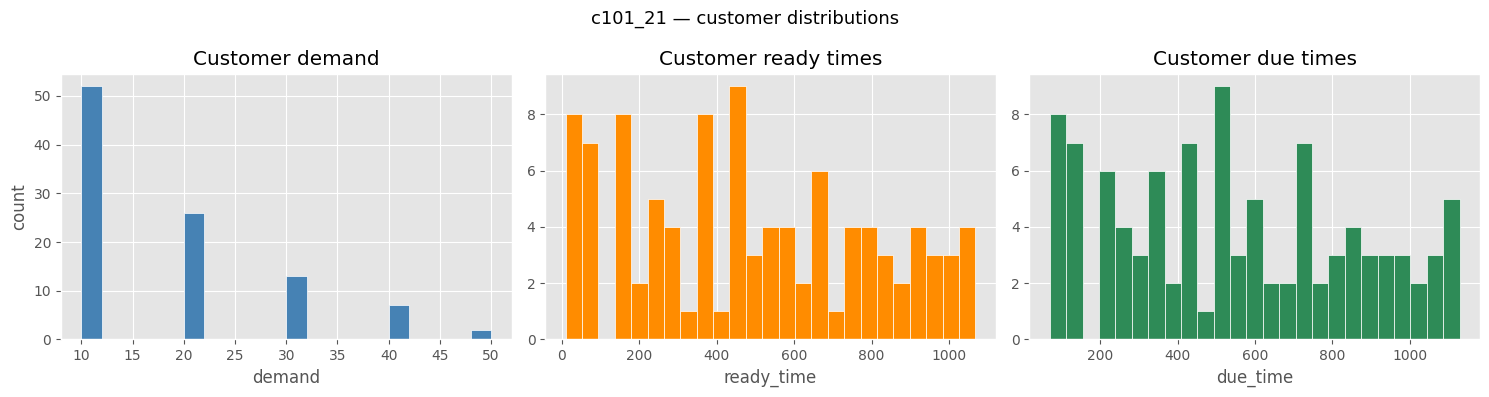

In [9]:
# Histograms: customer demands and time windows
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(customers["demand"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Customer demand")
axes[0].set_xlabel("demand")
axes[0].set_ylabel("count")

axes[1].hist(customers["ready_time"], bins=25, color="darkorange", edgecolor="white")
axes[1].set_title("Customer ready times")
axes[1].set_xlabel("ready_time")

axes[2].hist(customers["due_time"], bins=25, color="seagreen", edgecolor="white")
axes[2].set_title("Customer due times")
axes[2].set_xlabel("due_time")

plt.suptitle(f"{example_name} — customer distributions", fontsize=13)
plt.tight_layout()
plt.show()

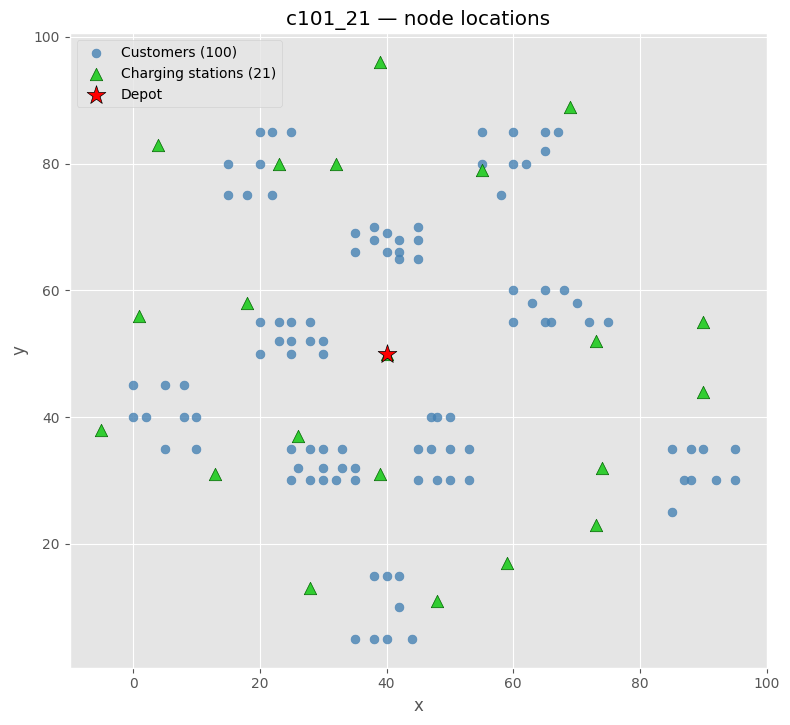

In [10]:
# Scatter plot: depot, customers, charging stations
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    customers["x"], customers["y"],
    c="steelblue", s=40, alpha=0.8, label=f"Customers ({len(customers)})", zorder=2,
)
ax.scatter(
    stations["x"], stations["y"],
    c="limegreen", s=80, marker="^", edgecolors="darkgreen",
    label=f"Charging stations ({len(stations)})", zorder=3,
)
ax.scatter(
    depots["x"], depots["y"],
    c="red", s=200, marker="*", edgecolors="black",
    label="Depot", zorder=4,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{example_name} — node locations")
ax.legend(loc="best")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

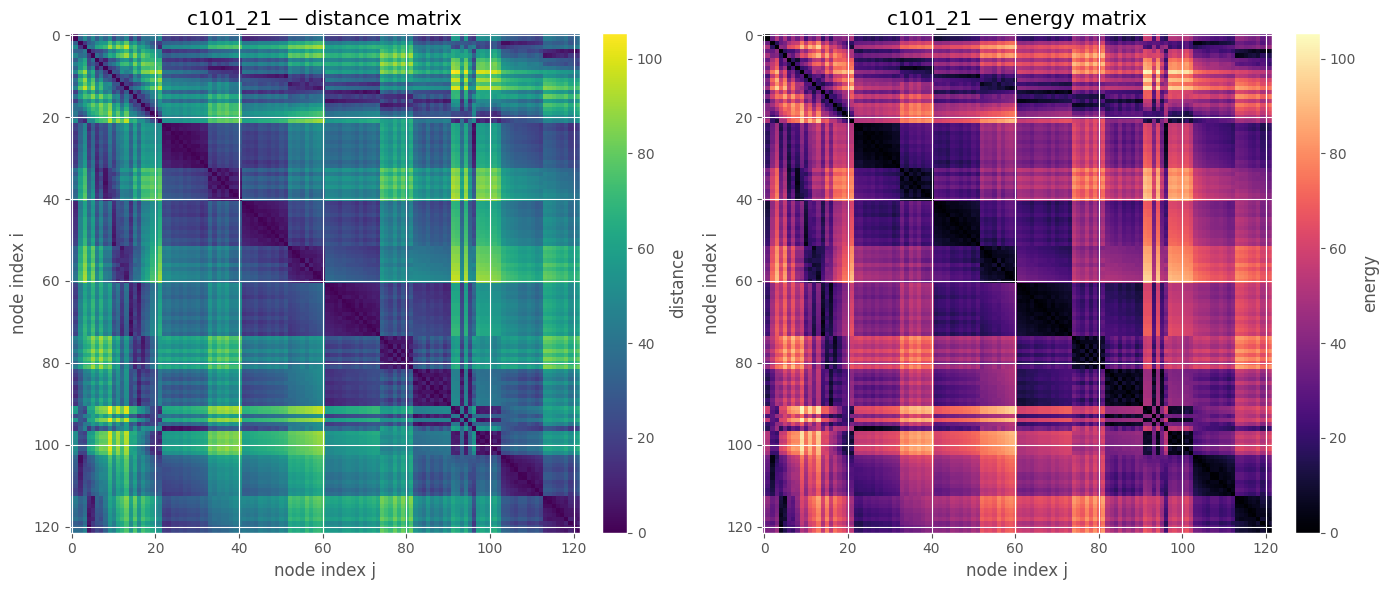

In [11]:
# Distance and energy matrix heatmaps
dist_mat = ex_matrices["distance_matrix"]
energy_mat = ex_matrices["energy_matrix"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(dist_mat, cmap="viridis", aspect="auto")
axes[0].set_title(f"{example_name} — distance matrix")
axes[0].set_xlabel("node index j")
axes[0].set_ylabel("node index i")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="distance")

im1 = axes[1].imshow(energy_mat, cmap="magma", aspect="auto")
axes[1].set_title(f"{example_name} — energy matrix")
axes[1].set_xlabel("node index j")
axes[1].set_ylabel("node index i")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="energy")

plt.tight_layout()
plt.show()

In [12]:
# Summary table for all converted instances
print("Summary table — all converted instances:")
display(summary_df.sort_values("instance_name").reset_index(drop=True))

Summary table — all converted instances:


,instance_name,num_nodes,num_customers,num_charging_stations,battery_capacity,load_capacity,energy_consumption_rate,inverse_charging_rate,speed,planning_horizon
0,c101C10,16,10,5,77.75,200.0,1.0,3.47,1.0,1236.0
1,c101C5,9,5,3,77.75,200.0,1.0,3.47,1.0,1236.0
2,c101_21,122,100,21,79.69,200.0,1.0,3.39,1.0,1236.0
3,c102_21,122,100,21,79.69,200.0,1.0,3.39,1.0,1236.0
4,c103C15,21,15,5,77.75,200.0,1.0,3.47,1.0,1236.0
...,...,...,...,...,...,...,...,...,...,...
87,rc205_21,122,100,21,194.58,1000.0,1.0,0.15,1.0,960.0
88,rc206_21,122,100,21,229.26,1000.0,1.0,0.13,1.0,960.0
89,rc207_21,122,100,21,212.23,1000.0,1.0,0.14,1.0,960.0
90,rc208C5,9,5,3,77.75,1000.0,1.0,0.39,1.0,960.0


## 7. Validation checks

In [13]:
if all_validation_errors:
    print(f"VALIDATION FAILED — {len(all_validation_errors)} error(s):")
    for err in all_validation_errors:
        print(f"  - {err}")
else:
    print("All validation checks passed for every converted instance.")
    print("\nChecks performed per instance:")
    checks = [
        "exactly one depot",
        "at least one customer",
        "at least one charging station",
        "all customers have valid demand (> 0)",
        "all stations have zero demand",
        "battery_capacity > 0",
        "load_capacity > 0",
        "energy_consumption_rate > 0",
        "inverse_charging_rate > 0",
        "speed > 0",
        "distance / travel_time / energy matrices are square",
        "matrix diagonals are zero",
        "ready_time <= due_time for all customers",
        "all nodes have finite x, y coordinates",
    ]
    for c in checks:
        print(f"  ✓ {c}")

All validation checks passed for every converted instance.

Checks performed per instance:
  ✓ exactly one depot
  ✓ at least one customer
  ✓ at least one charging station
  ✓ all customers have valid demand (> 0)
  ✓ all stations have zero demand
  ✓ battery_capacity > 0
  ✓ load_capacity > 0
  ✓ energy_consumption_rate > 0
  ✓ inverse_charging_rate > 0
  ✓ speed > 0
  ✓ distance / travel_time / energy matrices are square
  ✓ matrix diagonals are zero
  ✓ ready_time <= due_time for all customers
  ✓ all nodes have finite x, y coordinates


## 8. Reachability warnings

For each customer `j`:

```python
required_energy = energy[depot, j] + min(energy[j, r] for r in rechargeable_indices)
```

If `required_energy > battery_capacity`, the customer may require intermediate charging.

In [14]:
if all_reachability_warnings:
    print(f"Reachability warnings: {len(all_reachability_warnings)} total\n")
    # Show first 20 warnings; full list may be long for large batches
    for w in all_reachability_warnings[:20]:
        print(f"  WARNING: {w}")
    if len(all_reachability_warnings) > 20:
        print(f"\n  ... and {len(all_reachability_warnings) - 20} more warnings")
else:
    print("No reachability warnings — all customers reachable with depot round-trip energy.")

Reachability warnings: 21 total


  ... and 1 more warnings


## 9. Conversion complete — final report

In [15]:
print("Conversion completed.")
print(f"Raw folder: dataset/vrptw_instances/")
print(f"Converted folder: dataset/evrptw_instances/")
print(f"Number of converted instances: {len(conversion_records)}")
print()
display(summary_df.sort_values("instance_name").reset_index(drop=True))

Conversion completed.
Raw folder: dataset/vrptw_instances/
Converted folder: dataset/evrptw_instances/
Number of converted instances: 92



,instance_name,num_nodes,num_customers,num_charging_stations,battery_capacity,load_capacity,energy_consumption_rate,inverse_charging_rate,speed,planning_horizon
0,c101C10,16,10,5,77.75,200.0,1.0,3.47,1.0,1236.0
1,c101C5,9,5,3,77.75,200.0,1.0,3.47,1.0,1236.0
2,c101_21,122,100,21,79.69,200.0,1.0,3.39,1.0,1236.0
3,c102_21,122,100,21,79.69,200.0,1.0,3.39,1.0,1236.0
4,c103C15,21,15,5,77.75,200.0,1.0,3.47,1.0,1236.0
...,...,...,...,...,...,...,...,...,...,...
87,rc205_21,122,100,21,194.58,1000.0,1.0,0.15,1.0,960.0
88,rc206_21,122,100,21,229.26,1000.0,1.0,0.13,1.0,960.0
89,rc207_21,122,100,21,212.23,1000.0,1.0,0.14,1.0,960.0
90,rc208C5,9,5,3,77.75,1000.0,1.0,0.39,1.0,960.0
